In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('glints_jobs_clean.csv')

# Cek informasi dasar untuk menjawab tugas preprocessing Pekan 1
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1879 entries, 0 to 1878
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Judul               1879 non-null   object
 1   Industri            1879 non-null   object
 2   Tipe                1879 non-null   object
 3   Kategori            1879 non-null   object
 4   Tanggal_Post        1879 non-null   object
 5   Berlaku_Hingga      1879 non-null   object
 6   Perusahaan          1879 non-null   object
 7   Website_Perusahaan  1879 non-null   object
 8   Logo_Perusahaan     1879 non-null   object
 9   Alamat              1879 non-null   object
 10  Kota                1879 non-null   object
 11  Provinsi            1879 non-null   object
 12  Negara              1879 non-null   object
 13  Latitude            1879 non-null   object
 14  Longitude           1879 non-null   object
 15  Gaji_Min            1879 non-null   object
 16  Gaji_Max            1879

,Judul,Industri,Tipe,Kategori,Tanggal_Post,Berlaku_Hingga,Perusahaan,Website_Perusahaan,Logo_Perusahaan,Alamat,...,Gaji_Currency,Gaji_Unit,Skills,Pengalaman_Bulan,Pendidikan,Deskripsi,Tentang_Perusahaan,Benefit,Apply_Langsung,Link
0,IT Business Analyst,Information Technology and Services,FULL_TIME,System Analyst,2025-04-30T04:48:42.174Z,2026-05-03,PT Venturium System Indonesia,http://www.vensys.co.id,https://images.glints.com/unsafe/glints-dashbo...,JL Utan Kayu Raya No 14,...,Tidak ada,Tidak ada,"SQL, Business Analysis, Relational Databases, ...",36.0,bachelor degree,Job description \n \n Evaluating and documenti...,Tidak ada,Tidak ada,True,https://glints.com/id/opportunities/jobs/it-bu...
1,IT System Analyst,Information Technology and Services,FULL_TIME,System Analyst,2026-03-31T08:57:24.429Z,2026-05-01,Integrasi Optimal Visitama (IOV),https://iov.co.id/,https://images.glints.com/unsafe/glints-dashbo...,Surabaya,...,IDR,MONTH,"Requirements Analysis, SQL, Business Analysis,...",12.0,bachelor degree,General Qualification : \n \n Man (23 - 35 yea...,Integrasi Optimal Visitama (IOV) bergerak dibi...,"medical coverage, bpjs tenaga kerja insurance ...",True,https://glints.com/id/opportunities/jobs/it-sy...
2,IT Business Analyst - Insurance exp,Information Technology and Services,CONTRACTOR,Business Analyst,2025-06-04T04:13:18.761Z,2026-05-06,PT Sigma Global Teknologi,https://www.sigma-tech.co.id,https://images.glints.com/unsafe/glints-dashbo...,"Sona Topas Tower Lt. 12, Jl. Jend. Sudirman, R...",...,IDR,MONTH,"SDLC, Life Insurance, Teamwork, Business Proce...",36.0,bachelor degree,Skill And Experience : \n - Understand the Bas...,SIGMATECH is the enterprise technology partner...,Tidak ada,True,https://glints.com/id/opportunities/jobs/it-bu...
3,IT Business Analyst (for Insurance industry),Information Technology and Services,CONTRACTOR,Business Analyst,2025-02-03T09:07:51.181Z,2026-04-30,PT Sigma Global Teknologi,https://www.sigma-tech.co.id,https://images.glints.com/unsafe/glints-dashbo...,"Sona Topas Tower Lt. 12, Jl. Jend. Sudirman, R...",...,IDR,MONTH,"Csm, SQL, Insurance, Group Asia, SDLC, Life 40...",36.0,bachelor degree,Understand the Basic Life Insurance business r...,SIGMATECH is the enterprise technology partner...,Tidak ada,True,https://glints.com/id/opportunities/jobs/it-bu...
4,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,...,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,Tidak ada,https://glints.com/id/opportunities/jobs/it-bu...


/tmp/ipykernel_5909/3317557199.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')


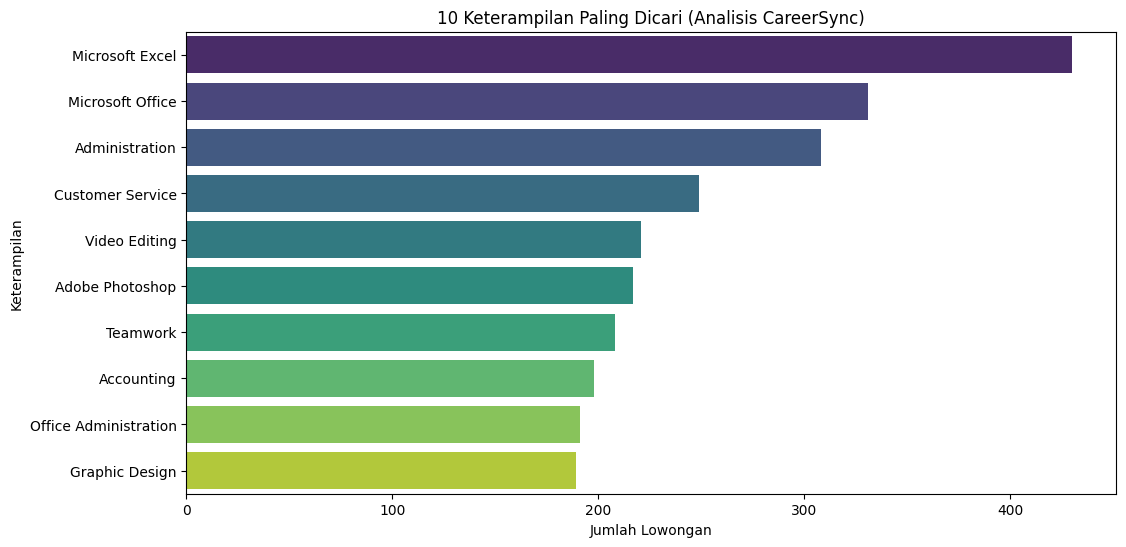

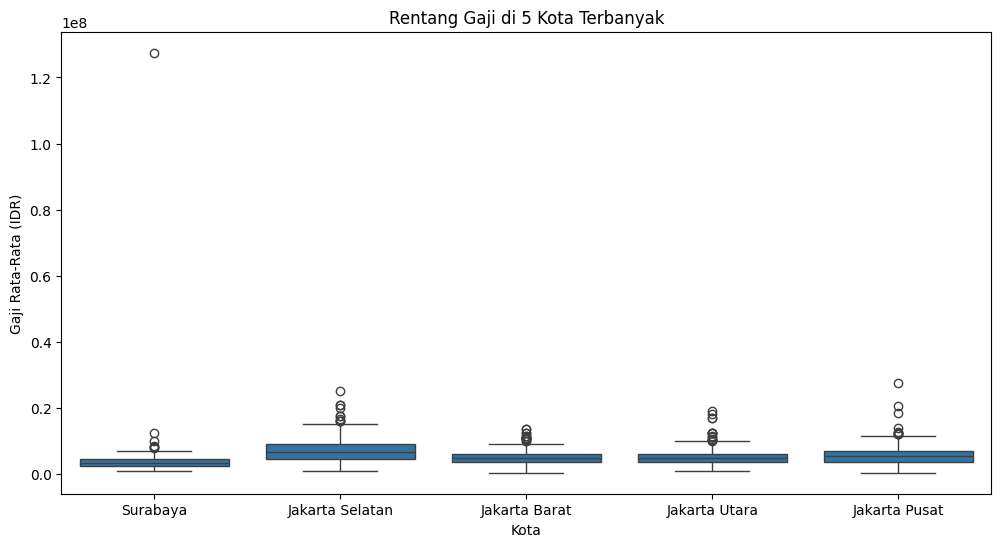

Total data yang dianalisis: 1879 lowongan
Keterampilan nomor 1 yang paling dicari adalah: Microsoft Excel


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('glints_jobs_clean.csv')

# 2. FEATURE ENGINEERING
# Menghitung Gaji Rata-rata dari kolom yang sudah ada di filemu
# Kita abaikan data yang isinya "Tidak ada" agar bisa dihitung secara matematis
df['Gaji_Min_Clean'] = pd.to_numeric(df['Gaji_Min'], errors='coerce')
df['Gaji_Max_Clean'] = pd.to_numeric(df['Gaji_Max'], errors='coerce')
df['Gaji_Rata_Rata'] = (df['Gaji_Min_Clean'] + df['Gaji_Max_Clean']) / 2

# 3. EDA - 10 Keterampilan Paling Dicari (Menjawab Pertanyaan Bisnis 1)
plt.figure(figsize=(12, 6))
# Kolom di filemu namanya 'Skills'
skills_series = df['Skills'].dropna().str.split(',').explode().str.strip()
top_skills = skills_series.value_counts().head(10)

sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')
plt.title('10 Keterampilan Paling Dicari (Analisis CareerSync)')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Keterampilan')
plt.show()

# 4. EDA - Distribusi Gaji Berdasarkan Kota (Menjawab Pertanyaan Bisnis 3)
plt.figure(figsize=(12, 6))
# Kolom di filemu namanya 'Kota'
top_cities = df['Kota'].value_counts().head(5).index
df_top_cities = df[df['Kota'].isin(top_cities)].copy()

sns.boxplot(data=df_top_cities, x='Kota', y='Gaji_Rata_Rata')
plt.title('Rentang Gaji di 5 Kota Terbanyak')
plt.ylabel('Gaji Rata-Rata (IDR)')
plt.xlabel('Kota')
plt.show()

# 5. Tampilkan ringkasan singkat untuk laporanmu
print(f"Total data yang dianalisis: {len(df)} lowongan")
print(f"Keterampilan nomor 1 yang paling dicari adalah: {top_skills.index[0]}")

In [4]:
# Simpan ke CSV baru untuk diserahkan ke tim AI
df.to_csv('glints_cleaned_for_model.csv', index=False)
print("File glints_cleaned_for_model.csv berhasil dibuat!")

File glints_cleaned_for_model.csv berhasil dibuat!
